In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy.stats import ks_2samp
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df = pd.read_csv(df_path)

In [3]:
df.head()

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y
0,71,100083,0,0,103500.0,573628.5,24435.0,463500.0,0.009657,-15406,...,1,0,0,0,1,1,0,1,0,1
1,124,100145,0,1,202500.0,260725.5,16789.5,198000.0,0.018850,-16282,...,1,0,0,0,1,1,0,1,0,1
2,143,100165,0,0,175500.0,1293502.5,35568.0,1129500.0,0.018850,-21961,...,1,0,0,0,1,1,0,1,0,1
3,152,100179,0,0,202500.0,675000.0,53329.5,675000.0,0.031329,-11375,...,1,0,0,1,0,1,0,1,0,1
4,161,100190,0,0,162000.0,263686.5,24781.5,238500.0,0.022625,-13972,...,1,0,0,1,0,1,0,1,0,1


In [4]:
# split into features and target
X, y = df.drop(columns=['TARGET', 'SK_ID_CURR', 'Unnamed: 0']), df['TARGET']

# the target column is not a feature, the SK_ID_CURR is an identifier, and the AGE_BUCKET is not numerical

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Define a function to evaluate the model

What to include:
- Best F1 threshold score
- KS statistic
- AUPRC (average precision)
- AUROC
- Gini

In [5]:
# function will take trained model, along with test data, and produce dataframe with results

def evaluate_model(algorithm, model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    # auroc
    auroc = roc_auc_score(y_test, y_prob)
    # gini
    gini = (2 * auroc) - 1
    # ks
    ks = ks_2samp(y_prob[y_test == 0], y_prob[y_test == 1]).statistic
    # auprc
    auprc = average_precision_score(y_test, y_prob)
    # optimal threshold for f1
    thresholds = np.arange(0.01, 1.00, 0.01)
    best_threshold = 0.5
    best_f1 = 0

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    # get info to be able to plot ROC and PR curves
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

    return {
        "Model": algorithm,
        "AUROC": auroc,
        "Gini": gini,
        "KS": ks,
        "AUPRC": auprc,
        "Best Threshold": best_threshold,
        "F1": best_f1,
        "ROC Curve": (fpr, tpr, roc_thresholds),
        "PR Curve": (precision, recall, pr_thresholds)
    }

In [6]:
def display_results(results):
    display({k: v for k, v in results.items() if k not in ['ROC Curve', 'PR Curve']})

### Create Pipeline 

In [7]:
numeric_cols = X_train.select_dtypes(include="number").columns

# numeric columns will be standardized
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)]
)

### Logistic Regression Baseline

In [8]:
lr_pipeline = Pipeline(
    [('preprocesser', preprocessor),
    ('model', LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced'))
    ]
)

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocesser', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
lr_results = evaluate_model("Logistic Regression", lr_pipeline, X_test, y_test)
display_results(lr_results)

{'Model': 'Logistic Regression',
 'AUROC': 0.7347894449001914,
 'Gini': 0.46957888980038276,
 'KS': 0.37202099240655434,
 'AUPRC': 0.19258911283291544,
 'Best Threshold': 0.8,
 'F1': 0.26973684210526316}

### Random Forest

In [10]:
random_forest_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced'))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
rf_results = evaluate_model("Random Forest", random_forest_pipeline, X_test, y_test)
display_results(rf_results)

{'Model': 'Random Forest',
 'AUROC': 0.7429061231358195,
 'Gini': 0.485812246271639,
 'KS': 0.37908857617635305,
 'AUPRC': 0.15181168331633688,
 'Best Threshold': 0.35000000000000003,
 'F1': 0.23230974632843793}

### XGBoost

In [12]:
xgboost_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(n_estimators=200, max_depth=20, scale_pos_weight=1))
    ]
)

xgboost_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
xgboost_results = evaluate_model("XGBoost", xgboost_pipeline, X_test, y_test)
display_results(xgboost_results)

{'Model': 'XGBoost',
 'AUROC': 0.7090485055005153,
 'Gini': 0.4180970110010307,
 'KS': 0.3388916934856229,
 'AUPRC': 0.16280837362525455,
 'Best Threshold': 0.01,
 'F1': 0.2302771855010661}

### Comparison table of all models + all results

In [14]:
comparison_df = pd.DataFrame([lr_results, rf_results, xgboost_results]).drop(columns=['ROC Curve', 'PR Curve'])
display(comparison_df)

,Model,AUROC,Gini,KS,AUPRC,Best Threshold,F1
0,Logistic Regression,0.734789,0.469579,0.372021,0.192589,0.80,0.269737
1,Random Forest,0.742906,0.485812,0.379089,0.151812,0.35,0.232310
2,XGBoost,0.709049,0.418097,0.338892,0.162808,0.01,0.230277


Random Forest wins on AUROC (by the slightest margin), and baseline Logistic Regression wins on AUPRC

### Plotting curves

#### First figure - ROC curve

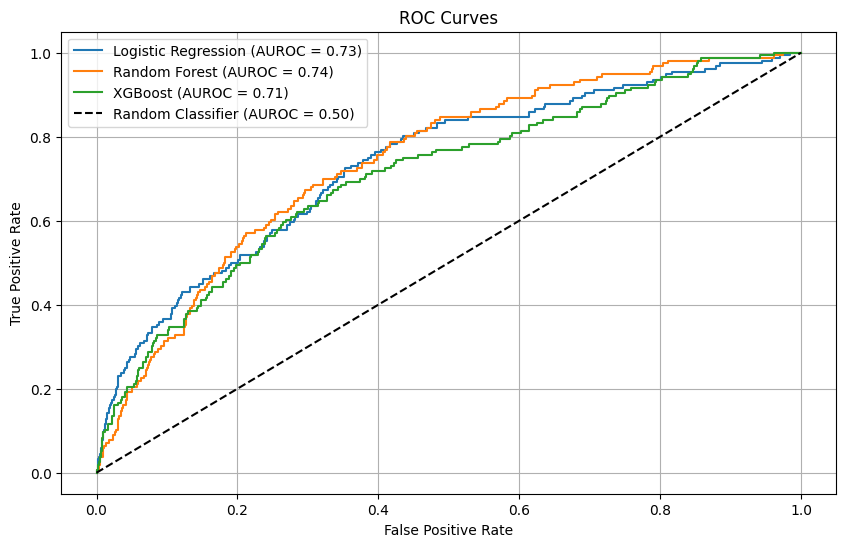

In [15]:
def plot_roc_curves():
    plt.figure(figsize=(10, 6))
    for results in [lr_results, rf_results, xgboost_results]:
        fpr, tpr, _ = results['ROC Curve']
        plt.plot(fpr, tpr, label=f"{results['Model']} (AUROC = {results['AUROC']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUROC = 0.50)')
    plt.title('ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

plot_roc_curves()

#### Second figure - Precision Recall Curve

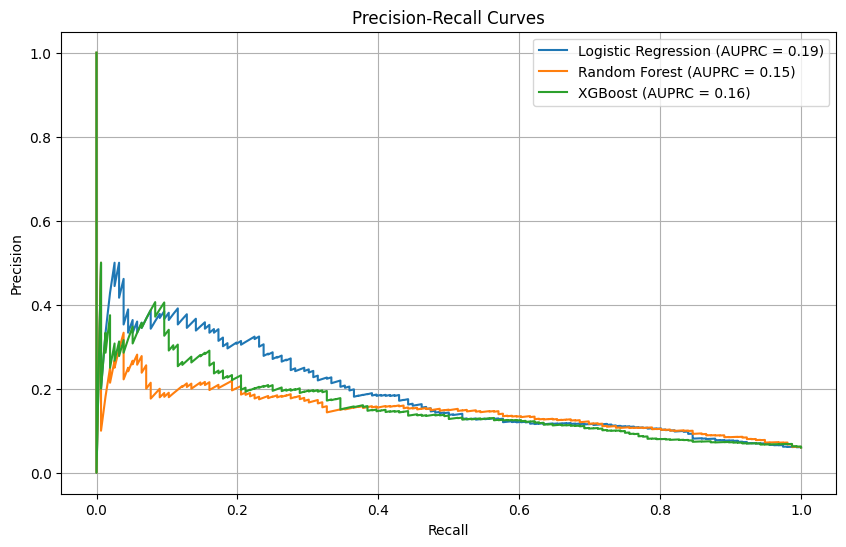

In [16]:
def plot_precision_recall_curves():
    plt.figure(figsize=(10, 6))
    for results in [lr_results, rf_results, xgboost_results]:
        precision, recall, _ = results['PR Curve']
        plt.plot(recall, precision, label=f"{results['Model']} (AUPRC = {results['AUPRC']:.2f})")
    plt.title('Precision-Recall Curves')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

plot_precision_recall_curves()

### Stratified K-Fold CV

Here we will use cross-validation to determine the best model. This involves training each model across 5 folds (splits), then taking the mean and std of AUROC across folds

In [17]:
pipelines = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': random_forest_pipeline,
    'XGBoost': xgboost_pipeline
}

# define one cv object and use across all pipelines so that differences are due to the models and not the data
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfolds_cv_results = {}

In [18]:
def cross_validate(results_dict, pipelines, X_train, y_train, cv_object):
    for name, pipeline in pipelines.items():
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv_object, scoring='roc_auc')
        results_dict[name] = {
            'Mean AUROC': np.mean(scores),
            'Std AUROC': np.std(scores)
        }

cross_validate(kfolds_cv_results, pipelines, X, y, cv)

In [19]:
kfolds_cv_results

{'Logistic Regression': {'Mean AUROC': 0.7187722595293012,
  'Std AUROC': 0.01695574112497582},
 'Random Forest': {'Mean AUROC': 0.7312693512371771,
  'Std AUROC': 0.011784684693507906},
 'XGBoost': {'Mean AUROC': 0.7087945001788041,
  'Std AUROC': 0.014415091320969929}}

It appears that the Random Forest classifier performs the best across the three models. Not only does it have the highest AUROC, it also has the lowest standard deviation. This will be our "champion" model moving forward

### RandomizedSearchCV

In [20]:
# define search paramters for random forest

param_dist = {
    "model__n_estimators": [100, 200, 300, 500], # number of trees
    "model__max_depth": [3, 5, 10, None], # max depth from root to leaves
    "model__min_samples_split": [2, 5, 10], # minimum number of samples required to split an internal node
    "model__min_samples_leaf": [1, 2, 5], # minimum number of samples required to be at a leaf node
    "model__max_features": ["sqrt", "log2"] # maximum number of features to consider when looking for the best split
}

search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [21]:
search.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,Pipeline(step...mators=200))])
,param_distributions,"{'model__max_depth': [3, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,50
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
print("Best AUROC:", search.best_score_)
print("Best params:", search.best_params_)

Best AUROC: 0.7392265667912327
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}


### Saving the model using joblib

In [23]:
import joblib
model_path = Path(f"{os.getcwd()}/../models/best_model.pkl")
joblib.dump(search.best_estimator_, model_path)

['c:\\Users\\alann\\OneDrive\\Desktop\\Coding\\Jarvis Talent Incubation Training\\jarvis_data_eng_AlanHu\\machine_learning\\module1\\capstone\\notebooks\\..\\models\\best_model.pkl']